# F1-RaceIQ-Suite: Naive Bayes Classifier

## Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, precision_score,
                              recall_score, f1_score)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Step 2 — Load the Cleaned Dataset

In [2]:
df = pd.read_csv('cleaned_f1_data.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 6939 rows, 19 columns


,Season,Round,Race Name,Date,Circuit,Country,Latitude,Longitude,Driver,Driver Nationality,Driver Age,Constructor,Grid Position,Race Position,Points Earned,Fastest Lap (s),Fastest Lap Rank,Laps Completed,Status
0,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Nino Farina,Italian,44,Alfa Romeo,1,1,9.0,90.239026,-1,70,Finished
1,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Reg Parnell,British,39,Alfa Romeo,4,3,4.0,90.239026,-1,70,Finished
2,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Yves Cabantous,French,46,Talbot-Lago,6,4,3.0,90.239026,-1,68,+2 Laps
3,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Louis Rosier,French,45,Talbot-Lago,9,5,2.0,90.239026,-1,68,+2 Laps
4,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Bob Gerard,British,36,ERA,13,6,0.0,90.239026,-1,67,+3 Laps


## Step 3 — Drop Irrelevant Columns

In [3]:
to_drop = ['Season', 'Round', 'Race Name', 'Date', 'Country',
           'Driver Nationality', 'Driver', 'Points Earned',
           'Latitude', 'Longitude']

df = df.drop(columns=to_drop, errors='ignore')
print("Remaining columns:", list(df.columns))
print("Shape after dropping:", df.shape)

Remaining columns: ['Circuit', 'Driver Age', 'Constructor', 'Grid Position', 'Race Position', 'Fastest Lap (s)', 'Fastest Lap Rank', 'Laps Completed', 'Status']
Shape after dropping: (6939, 9)


## Step 4 — Fix Placeholder Values in Fastest Lap Rank



In [4]:
df['Fastest Lap Rank'] = df['Fastest Lap Rank'].replace(-1, 0)
print("Fastest Lap Rank min value after fix:", df['Fastest Lap Rank'].min())
print("Value counts for 0 (previously -1):", (df['Fastest Lap Rank'] == 0).sum())

Fastest Lap Rank min value after fix: 0
Value counts for 0 (previously -1): 4928


## Step 5 — Feature Engineering





In [5]:
df['Grid Position Binary'] = (df['Grid Position'] <= 10).astype(int)
df['Driver Age Binary'] = (df['Driver Age'] > 30).astype(int)
df['Laps Completed Binary'] = (df['Laps Completed'] > 50).astype(int)

# NEW: binary version of the continuous lap-time feature, for Bernoulli NB
lap_median = df['Fastest Lap (s)'].median()
df['Fast_Lap_Binary'] = (df['Fastest Lap (s)'] < lap_median).astype(int)

df = df.drop(['Grid Position', 'Driver Age', 'Laps Completed'], axis=1)
print("Binary features created.")
print("Columns now:", list(df.columns))

Binary features created.
Columns now: ['Circuit', 'Constructor', 'Race Position', 'Fastest Lap (s)', 'Fastest Lap Rank', 'Status', 'Grid Position Binary', 'Driver Age Binary', 'Laps Completed Binary', 'Fast_Lap_Binary']


## Step 6 — Define the Target Variable



In [6]:
df['Position_Category'] = (df['Race Position'] <= 10).astype(int)
df = df.drop(['Race Position'], axis=1)

print("Target variable distribution:")
print(df['Position_Category'].value_counts())
total = len(df)
points = df['Position_Category'].sum()
print(f"\nClass balance: {points/total*100:.1f}% Points, {(total-points)/total*100:.1f}% No Points")

Target variable distribution:
Position_Category
0    3590
1    3349
Name: count, dtype: int64

Class balance: 48.3% Points, 51.7% No Points


## Step 7 — Build TWO Versions of the Feature Set



In [7]:
categorical_cols = ['Circuit', 'Constructor', 'Status']
categorical_cols = [c for c in categorical_cols if c in df.columns]
print("Categorical columns:", categorical_cols)


df_a = df.copy()
categories_list = [df_a[col].unique().tolist() for col in categorical_cols]
ord_encoder = OrdinalEncoder(categories=categories_list)
df_a[categorical_cols] = ord_encoder.fit_transform(df_a[categorical_cols])

X_a = df_a.drop(['Position_Category'], axis=1)
y = df_a['Position_Category']

print("X_a (Gaussian) shape:", X_a.shape)
X_a.head()

Categorical columns: ['Circuit', 'Constructor', 'Status']
X_a (Gaussian) shape: (6939, 9)


,Circuit,Constructor,Fastest Lap (s),Fastest Lap Rank,Status,Grid Position Binary,Driver Age Binary,Laps Completed Binary,Fast_Lap_Binary
0,0.0,0.0,90.239026,0,0.0,1,1,1,0
1,0.0,0.0,90.239026,0,0.0,1,1,1,0
2,0.0,1.0,90.239026,0,1.0,1,1,1,0
3,0.0,1.0,90.239026,0,1.0,1,1,1,0
4,0.0,2.0,90.239026,0,2.0,0,1,1,0


In [8]:

# Version B — for Multinomial NB and Bernoulli NB
# One-hot encoded categoricals, no ordinal ranking implied
# Raw continuous lap-time column dropped (Fast_Lap_Binary used instead)

df_b = df.copy()
df_b = pd.get_dummies(df_b, columns=categorical_cols, drop_first=False)
df_b = df_b.drop(['Fastest Lap (s)'], axis=1, errors='ignore')
df_b = df_b.astype(int)

X_b = df_b.drop(['Position_Category'], axis=1)

print("X_b (Multinomial/Bernoulli) shape:", X_b.shape)
X_b.head()

X_b (Multinomial/Bernoulli) shape: (6939, 318)


,Fastest Lap Rank,Grid Position Binary,Driver Age Binary,Laps Completed Binary,Fast_Lap_Binary,Circuit_Aintree,Circuit_Albert Park Grand Prix Circuit,Circuit_Autodromo Enzo e Dino Ferrari,Circuit_Autódromo Hermanos Rodríguez,Circuit_Autódromo Internacional Nelson Piquet,...,Status_Tyre,Status_Vibrations,Status_Water leak,Status_Water pipe,Status_Water pump,Status_Wheel,Status_Wheel bearing,Status_Wheel nut,Status_Wheel rim,Status_Withdrew
0,0,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Step 8 — Train/Test Split (80/20, Stratified)



In [9]:
X_train_a, X_test_a, y_train, y_test = train_test_split(
    X_a, y, test_size=0.2, random_state=42, stratify=y
)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b, y, test_size=0.2, random_state=42, stratify=y
)
# y_train_b / y_test_b match y_train / y_test exactly since split params are identical

print(f"Training set: {X_train_a.shape[0]} rows")
print(f"Test set:     {X_test_a.shape[0]} rows")
print(f"X_a features: {X_train_a.shape[1]} columns")
print(f"X_b features: {X_train_b.shape[1]} columns")

Training set: 5551 rows
Test set:     1388 rows
X_a features: 9 columns
X_b features: 318 columns


## Step 10 — Model 1: Gaussian Naive Bayes (uses `X_a`)

In [10]:
gnb_model = GaussianNB()
gnb_model.fit(X_train_a, y_train)
y_pred_gnb = gnb_model.predict(X_test_a)

print("=" * 50)
print("MODEL 1 — Gaussian Naive Bayes")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_gnb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gnb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_gnb):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_gnb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gnb, target_names=['No Points', 'Points']))

MODEL 1 — Gaussian Naive Bayes
Accuracy:  0.8249
Precision: 0.8108
Recall:    0.8313
F1 Score:  0.8209

Classification Report:
              precision    recall  f1-score   support

   No Points       0.84      0.82      0.83       718
      Points       0.81      0.83      0.82       670

    accuracy                           0.82      1388
   macro avg       0.82      0.83      0.82      1388
weighted avg       0.83      0.82      0.82      1388



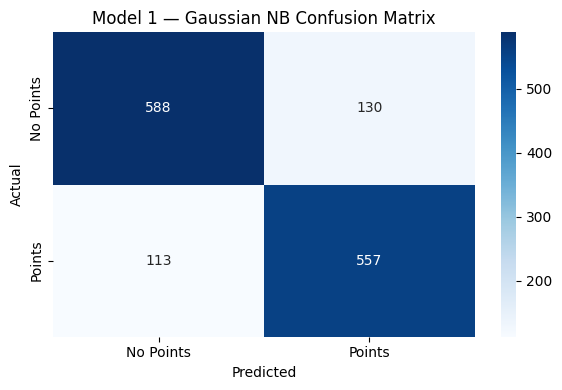

In [11]:
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Model 1 — Gaussian NB Confusion Matrix')
plt.tight_layout()
plt.show()

## Step 11 — Model 2: Multinomial Naive Bayes (uses `X_b`, alpha=1)

In [12]:
mnb_model = MultinomialNB(alpha=1)
mnb_model.fit(X_train_b, y_train_b)
y_pred_mnb = mnb_model.predict(X_test_b)

print("=" * 50)
print("MODEL 2 — Multinomial NB (alpha=1)")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test_b, y_pred_mnb):.4f}")
print(f"Precision: {precision_score(y_test_b, y_pred_mnb):.4f}")
print(f"Recall:    {recall_score(y_test_b, y_pred_mnb):.4f}")
print(f"F1 Score:  {f1_score(y_test_b, y_pred_mnb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_b, y_pred_mnb, target_names=['No Points', 'Points']))

MODEL 2 — Multinomial NB (alpha=1)
Accuracy:  0.8487
Precision: 0.8221
Recall:    0.8761
F1 Score:  0.8483

Classification Report:
              precision    recall  f1-score   support

   No Points       0.88      0.82      0.85       718
      Points       0.82      0.88      0.85       670

    accuracy                           0.85      1388
   macro avg       0.85      0.85      0.85      1388
weighted avg       0.85      0.85      0.85      1388



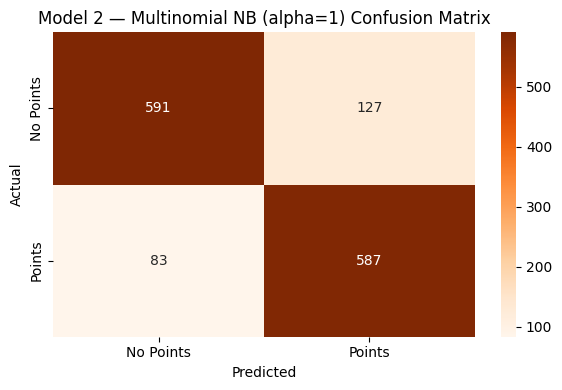

In [13]:
cm_mnb = confusion_matrix(y_test_b, y_pred_mnb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Model 2 — Multinomial NB (alpha=1) Confusion Matrix')
plt.tight_layout()
plt.show()

## Step 12 — Model 2b: Multinomial NB (alpha=0.5) — Tuned

In [14]:
mnb_tuned = MultinomialNB(alpha=0.5)
mnb_tuned.fit(X_train_b, y_train_b)
y_pred_mnb_tuned = mnb_tuned.predict(X_test_b)

print("=" * 50)
print("MODEL 2b — Multinomial NB (alpha=0.5)")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test_b, y_pred_mnb_tuned):.4f}")
print(f"Precision: {precision_score(y_test_b, y_pred_mnb_tuned):.4f}")
print(f"Recall:    {recall_score(y_test_b, y_pred_mnb_tuned):.4f}")
print(f"F1 Score:  {f1_score(y_test_b, y_pred_mnb_tuned):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_b, y_pred_mnb_tuned, target_names=['No Points', 'Points']))

MODEL 2b — Multinomial NB (alpha=0.5)
Accuracy:  0.8523
Precision: 0.8317
Recall:    0.8701
F1 Score:  0.8505

Classification Report:
              precision    recall  f1-score   support

   No Points       0.87      0.84      0.85       718
      Points       0.83      0.87      0.85       670

    accuracy                           0.85      1388
   macro avg       0.85      0.85      0.85      1388
weighted avg       0.85      0.85      0.85      1388



## Step 13 — Model 3: Bernoulli Naive Bayes (uses `X_b`, alpha=1)

In [15]:
bnb_model = BernoulliNB(alpha=1)
bnb_model.fit(X_train_b, y_train_b)
y_pred_bnb = bnb_model.predict(X_test_b)

print("=" * 50)
print("MODEL 3 — Bernoulli NB (alpha=1)")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test_b, y_pred_bnb):.4f}")
print(f"Precision: {precision_score(y_test_b, y_pred_bnb):.4f}")
print(f"Recall:    {recall_score(y_test_b, y_pred_bnb):.4f}")
print(f"F1 Score:  {f1_score(y_test_b, y_pred_bnb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_b, y_pred_bnb, target_names=['No Points', 'Points']))

MODEL 3 — Bernoulli NB (alpha=1)
Accuracy:  0.8408
Precision: 0.8193
Recall:    0.8597
F1 Score:  0.8390

Classification Report:
              precision    recall  f1-score   support

   No Points       0.86      0.82      0.84       718
      Points       0.82      0.86      0.84       670

    accuracy                           0.84      1388
   macro avg       0.84      0.84      0.84      1388
weighted avg       0.84      0.84      0.84      1388



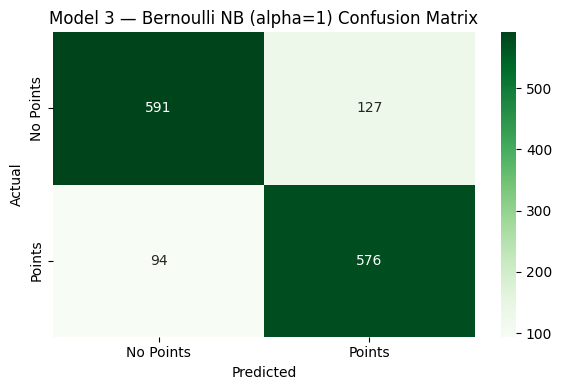

In [16]:
cm_bnb = confusion_matrix(y_test_b, y_pred_bnb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_bnb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Model 3 — Bernoulli NB (alpha=1) Confusion Matrix')
plt.tight_layout()
plt.show()

## Step 14 — Model 3b: Bernoulli NB (alpha=0.5) — Tuned

In [17]:
bnb_tuned = BernoulliNB(alpha=0.5)
bnb_tuned.fit(X_train_b, y_train_b)
y_pred_bnb_tuned = bnb_tuned.predict(X_test_b)

print("=" * 50)
print("MODEL 3b — Bernoulli NB (alpha=0.5)")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test_b, y_pred_bnb_tuned):.4f}")
print(f"Precision: {precision_score(y_test_b, y_pred_bnb_tuned):.4f}")
print(f"Recall:    {recall_score(y_test_b, y_pred_bnb_tuned):.4f}")
print(f"F1 Score:  {f1_score(y_test_b, y_pred_bnb_tuned):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_b, y_pred_bnb_tuned, target_names=['No Points', 'Points']))

MODEL 3b — Bernoulli NB (alpha=0.5)
Accuracy:  0.8408
Precision: 0.8203
Recall:    0.8582
F1 Score:  0.8388

Classification Report:
              precision    recall  f1-score   support

   No Points       0.86      0.82      0.84       718
      Points       0.82      0.86      0.84       670

    accuracy                           0.84      1388
   macro avg       0.84      0.84      0.84      1388
weighted avg       0.84      0.84      0.84      1388



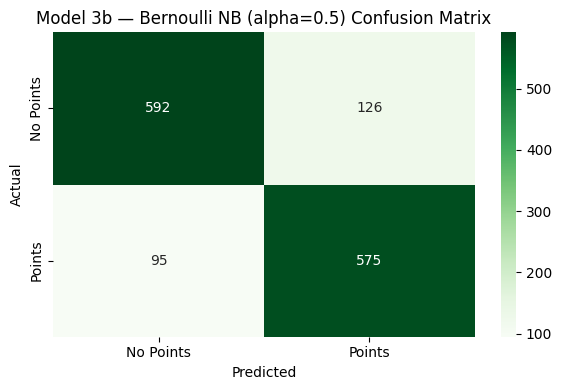

In [18]:
cm_bnb_tuned = confusion_matrix(y_test_b, y_pred_bnb_tuned)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_bnb_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Model 3b — Bernoulli NB (alpha=0.5) Confusion Matrix')
plt.tight_layout()
plt.show()

## Step 15 — All Naive Bayes Variants Comparison

In [19]:
results = pd.DataFrame({
    'Model': ['Gaussian NB', 'Multinomial (α=1)',
              'Multinomial (α=0.5)', 'Bernoulli (α=1)', 'Bernoulli (α=0.5)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_gnb),
        accuracy_score(y_test_b, y_pred_mnb),
        accuracy_score(y_test_b, y_pred_mnb_tuned),
        accuracy_score(y_test_b, y_pred_bnb),
        accuracy_score(y_test_b, y_pred_bnb_tuned)
    ],
    'Precision': [
        precision_score(y_test, y_pred_gnb),
        precision_score(y_test_b, y_pred_mnb),
        precision_score(y_test_b, y_pred_mnb_tuned),
        precision_score(y_test_b, y_pred_bnb),
        precision_score(y_test_b, y_pred_bnb_tuned)
    ],
    'Recall': [
        recall_score(y_test, y_pred_gnb),
        recall_score(y_test_b, y_pred_mnb),
        recall_score(y_test_b, y_pred_mnb_tuned),
        recall_score(y_test_b, y_pred_bnb),
        recall_score(y_test_b, y_pred_bnb_tuned)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_gnb),
        f1_score(y_test_b, y_pred_mnb),
        f1_score(y_test_b, y_pred_mnb_tuned),
        f1_score(y_test_b, y_pred_bnb),
        f1_score(y_test_b, y_pred_bnb_tuned)
    ]
})

print(results.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1 Score
        Gaussian NB  0.824928   0.810771 0.831343  0.820929
  Multinomial (α=1)  0.848703   0.822129 0.876119  0.848266
Multinomial (α=0.5)  0.852305   0.831669 0.870149  0.850474
    Bernoulli (α=1)  0.840778   0.819346 0.859701  0.839039
  Bernoulli (α=0.5)  0.840778   0.820257 0.858209  0.838804


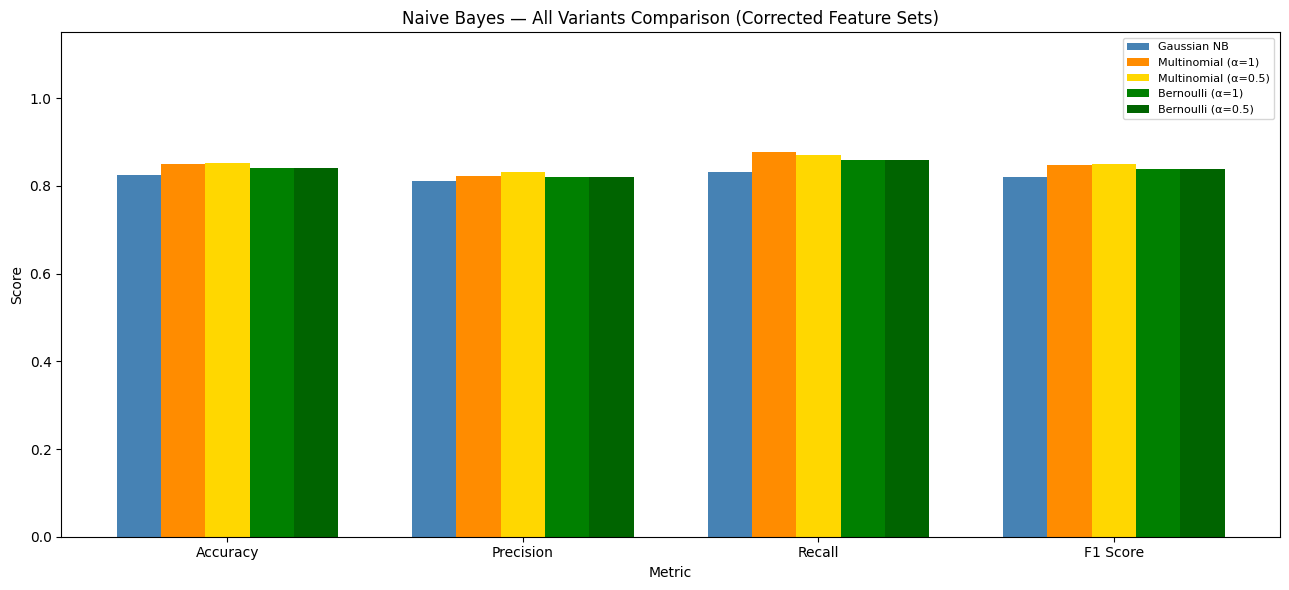

In [20]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.15
colors = ['steelblue', 'darkorange', 'gold', 'green', 'darkgreen']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (_, row) in enumerate(results.iterrows()):
    ax.bar(x + i * width, row[metrics], width,
           label=row['Model'], color=colors[i])

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Naive Bayes — All Variants Comparison (Corrected Feature Sets)')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()